# Final WLASL100 Validation Code fir I3D & TGCN

# I3D ASL Baseline Validation
### Reproducing the published WLASL-100 benchmark before PSL transfer

**Purpose:** Validate that our I3D inference pipeline correctly reproduces published 
accuracy on the source domain (ASL) before applying the same pipeline to PSL zero-shot 
and fine-tuning experiments.

**Model:** I3D pretrained on Kinetics, finetuned on WLASL-100  
**Published baseline:** Top-1: 65.89% | Top-5: 84.11% | Top-10: 89.92%  
**This is a validation step, not the final result** — the benchmark table comes from 
running this same architecture on PSL (Phase 2).

In [1]:
!pip install gdown yt-dlp opencv-python-headless -q
import torch, numpy as np, cv2, json, os, gc, sys, subprocess, urllib.request
import matplotlib.pyplot as plt

CONFIG = {
    "num_classes": 100,
    "max_frames": 64,
    "download_timeout": 60,
    "work_dir": "/kaggle/working/WLASL",
    "output_dir": "/kaggle/working/outputs",
    "ckpt_dir": "/kaggle/working/checkpoints",
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs(CONFIG["ckpt_dir"], exist_ok=True)

print("Setup complete")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")

Setup complete
PyTorch: 2.10.0+cu128 | CUDA: True


In [2]:
!rm -rf {CONFIG["work_dir"]}
!git clone https://github.com/dxli94/WLASL.git {CONFIG["work_dir"]}

json_path = f'{CONFIG["work_dir"]}/WLASL_v0.3.json'
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/dxli94/WLASL/master/start_kit/WLASL_v0.3.json",
    json_path
)
with open(json_path) as f:
    data = json.load(f)
print(f"JSON loaded: {len(data)} glosses (using first {CONFIG['num_classes']})")

import gdown
gdown.download("https://drive.google.com/file/d/1JgTRHGBRCHyHRT_rAF0fOjnfiFefXkEd/view",
               "/kaggle/working/K.zip", fuzzy=True, quiet=False)
gdown.download("https://drive.google.com/file/d/1jALimVOB69ifYkeT0Pe297S1z4U3jC48/view",
               "/kaggle/working/W.zip", fuzzy=True, quiet=False)
!unzip -q -o /kaggle/working/K.zip -d {CONFIG["work_dir"]}/code/I3D/
!unzip -q -o /kaggle/working/W.zip -d {CONFIG["work_dir"]}/code/I3D/
print("Weights ready")

Cloning into '/kaggle/working/WLASL'...
remote: Enumerating objects: 237, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 237 (delta 67), reused 54 (delta 54), pack-reused 129 (from 2)
Receiving objects: 100% (237/237), 3.73 MiB | 12.66 MiB/s, done.
Resolving deltas: 100% (97/97), done.
JSON loaded: 2000 glosses (using first 100)


Downloading...
From (original): https://drive.google.com/uc?id=1JgTRHGBRCHyHRT_rAF0fOjnfiFefXkEd
From (redirected): https://drive.google.com/uc?id=1JgTRHGBRCHyHRT_rAF0fOjnfiFefXkEd&confirm=t&uuid=6b9506bd-ff0d-4dfd-a6a3-9245282918e8
To: /kaggle/working/K.zip
100%|██████████| 187M/187M [00:06<00:00, 30.2MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1jALimVOB69ifYkeT0Pe297S1z4U3jC48
From (redirected): https://drive.google.com/uc?id=1jALimVOB69ifYkeT0Pe297S1z4U3jC48&confirm=t&uuid=7b0531e7-1008-45ab-b141-2dc3b4b2d1fe
To: /kaggle/working/W.zip
100%|██████████| 197M/197M [00:04<00:00, 39.7MB/s] 


Weights ready


In [3]:
vdir = f'{CONFIG["work_dir"]}/data/videos'
os.makedirs(vdir, exist_ok=True)

metadata, videos = {}, []
for entry in data[:CONFIG["num_classes"]]:
    gloss = entry["gloss"]
    for inst in entry["instances"]:
        if inst["split"] == "test":
            vid = inst["video_id"]
            videos.append((vid, inst["url"]))
            metadata[vid] = {"gloss": gloss, "bbox": inst["bbox"],
                              "f_start": inst["frame_start"], "f_end": inst["frame_end"]}

existing = [f.replace('.mp4','') for f in os.listdir(vdir) if f.endswith('.mp4')]
to_download = [(v,u) for v,u in videos if v not in existing]
print(f"Have: {len(existing)} | Need: {len(to_download)}")

success = list(existing)
for i, (vid, url) in enumerate(to_download):
    out = f"{vdir}/{vid}.mp4"
    try:
        p = subprocess.Popen(
            ["yt-dlp", "--quiet", "--no-warnings", "--ignore-errors",
             "-f", "best[ext=mp4]/best", "-o", out, url],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
        )
        p.wait(timeout=CONFIG["download_timeout"])
        if os.path.exists(out):
            success.append(vid)
    except subprocess.TimeoutExpired:
        p.kill()
    except:
        pass
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(to_download)} | Total: {len(success)}")

valid_metadata = {v: metadata[v] for v in success if v in metadata}
with open("/kaggle/working/valid_metadata.json", "w") as f:
    json.dump(valid_metadata, f)
print(f"\nDone. {len(valid_metadata)} videos with metadata ready for evaluation")

Have: 0 | Need: 258
  20/258 | Total: 7
  40/258 | Total: 18
  60/258 | Total: 30
  80/258 | Total: 48
  100/258 | Total: 59
  120/258 | Total: 71
  140/258 | Total: 82
  160/258 | Total: 95
  180/258 | Total: 103
  200/258 | Total: 118
  220/258 | Total: 132
  240/258 | Total: 147

Done. 158 videos with metadata ready for evaluation


In [4]:
%cd {CONFIG["work_dir"]}/code/I3D
sys.path.insert(0, f'{CONFIG["work_dir"]}/code/I3D')
from pytorch_i3d import InceptionI3d

model = InceptionI3d(400, in_channels=3)
model.load_state_dict(torch.load('weights/rgb_imagenet.pt'))
model.replace_logits(CONFIG["num_classes"])
model.load_state_dict(torch.load(
    'archived/asl100/FINAL_nslt_100_iters=896_top1=65.89_top5=84.11_top10=89.92.pt'
))
model.cuda().eval()

label_map = {i: e["gloss"] for i, e in enumerate(data[:CONFIG["num_classes"]])}
print("Model loaded — WLASL-100, published top1=65.89%")

/kaggle/working/WLASL/code/I3D
Model loaded — WLASL-100, published top1=65.89%


In [5]:
def load_video(path, vid, meta, max_f=64):
    m = meta.get(vid, {})
    bbox, fs, fe = m.get("bbox"), m.get("f_start", 1), m.get("f_end", -1)
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if fe == -1 or fe > total: fe = total
    fs = max(1, min(fs, total))
    n = min(max_f, fe - fs + 1)
    idx = np.linspace(fs-1, fe-1, n, dtype=int)

    frames = []
    for i in idx:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, img = cap.read()
        if ret:
            if bbox and len(bbox) == 4:
                x, y, x2, y2 = bbox
                h, w = img.shape[:2]
                x, y, x2, y2 = max(0,x), max(0,y), min(w,x2), min(h,y2)
                if x2 > x and y2 > y:
                    img = img[y:y2, x:x2]
            # Aspect-ratio preserving resize + center crop (matches original WLASL preprocessing)
            h, w = img.shape[:2]
            scale = 226 / min(h, w)
            img = cv2.resize(img, (int(w*scale), int(h*scale)))
            h, w = img.shape[:2]
            sy, sx = (h-224)//2, (w-224)//2
            img = img[max(0,sy):max(0,sy)+224, max(0,sx):max(0,sx)+224]
            img = (img / 255.) * 2 - 1
            frames.append(img)
    cap.release()
    if not frames: return None
    while len(frames) < max_f: frames.append(frames[-1])
    return torch.Tensor(np.array(frames)).permute(3, 0, 1, 2)

In [6]:
with open("/kaggle/working/valid_metadata.json") as f:
    meta = json.load(f)
vfiles = [f for f in os.listdir(vdir) if f.endswith('.mp4')]

top1_c = top5_c = top10_c = total = 0
top1_tp = np.zeros(CONFIG["num_classes"], dtype=int)
top1_fp = np.zeros(CONFIG["num_classes"], dtype=int)
predictions_log = []

print(f"Evaluating {len(vfiles)} videos...\n")
for i, vf in enumerate(vfiles):
    vid = vf.replace('.mp4', '')
    if vid not in meta: continue
    gt = meta[vid]["gloss"]
    gt_idx = next((idx for idx, g in label_map.items() if g == gt), None)
    if gt_idx is None: continue

    tensor = load_video(f"{vdir}/{vf}", vid, meta)
    if tensor is None: continue

    inp = tensor.unsqueeze(0).cuda()
    with torch.no_grad():
        out = model(inp).mean(dim=2)
        scores = out[0].cpu().numpy()
    top10_idx = np.argsort(scores)[::-1][:10]
    top1_idx = top10_idx[0]
    pred = label_map[top1_idx]

    t1, t5, t10 = gt_idx == top1_idx, gt_idx in top10_idx[:5], gt_idx in top10_idx
    if t1: top1_c += 1; top1_tp[gt_idx] += 1
    else: top1_fp[gt_idx] += 1
    if t5: top5_c += 1
    if t10: top10_c += 1
    total += 1
    predictions_log.append({"video_id": vid, "gt": gt, "pred": pred, "correct": bool(t1)})

    print(f"[{i+1:3d}] {vid} | GT: {gt:15} | Pred: {pred:15} | {'✓' if t1 else '✗'}")
    del tensor, inp, out
    torch.cuda.empty_cache(); gc.collect()

print(f"\n{'='*55}\n{'OVERALL RESULTS — WLASL-100':^55}\n{'='*55}")
print(f"Videos evaluated: {total}")
print(f"Top-1:  {top1_c/total*100:.2f}%  ({top1_c}/{total})")
print(f"Top-5:  {top5_c/total*100:.2f}%  ({top5_c}/{total})")
print(f"Top-10: {top10_c/total*100:.2f}%  ({top10_c}/{total})")
print(f"\nPublished baseline:  Top-1: 65.89% | Top-5: 84.11% | Top-10: 89.92%")
print(f"{'='*55}")

Evaluating 158 videos...

[  1] 34836 | GT: many            | Pred: tell            | ✗
[  2] 01386 | GT: africa          | Pred: deaf            | ✗
[  3] 53258 | GT: son             | Pred: bed             | ✗
[  4] 32258 | GT: last            | Pred: short           | ✗
[  5] 63201 | GT: white           | Pred: white           | ✓
[  6] 22117 | GT: fish            | Pred: fish            | ✓
[  7] 68132 | GT: pink            | Pred: mother          | ✗
[  8] 06366 | GT: birthday        | Pred: son             | ✗
[  9] 70271 | GT: cool            | Pred: bird            | ✗
[ 10] 32157 | GT: language        | Pred: later           | ✗
[ 11] 64275 | GT: yes             | Pred: short           | ✗
[ 12] 43171 | GT: play            | Pred: play            | ✓
[ 13] 12320 | GT: computer        | Pred: finish          | ✗
[ 14] 57941 | GT: thin            | Pred: shirt           | ✗
[ 15] 01394 | GT: africa          | Pred: white           | ✗
[ 16] 63675 | GT: woman           | Pred: wh

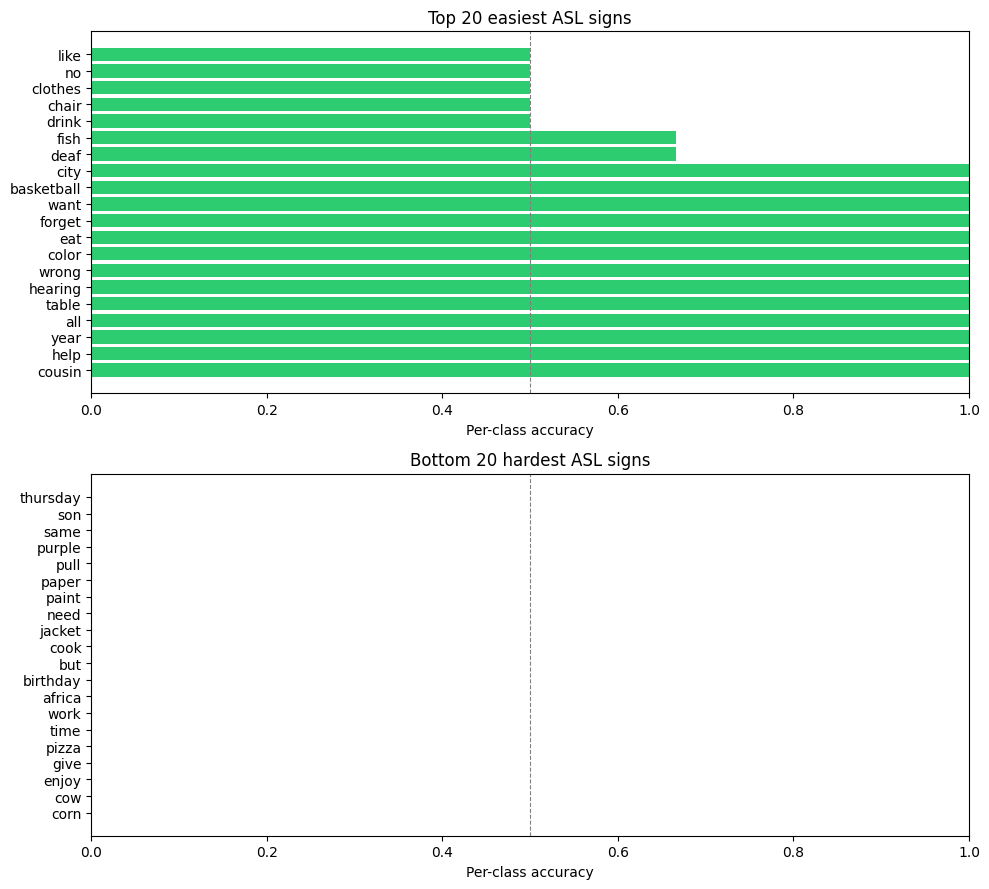

Saved per_class_accuracy.png


In [7]:
per_class = {}
for idx in range(CONFIG["num_classes"]):
    t = top1_tp[idx] + top1_fp[idx]
    if t > 0:
        per_class[label_map[idx]] = top1_tp[idx] / t

sorted_acc = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
N = min(20, len(sorted_acc)//2)

fig, axes = plt.subplots(2, 1, figsize=(10, 9))
for ax, subset, title, color in zip(
    axes, [sorted_acc[:N], sorted_acc[-N:]],
    [f"Top {N} easiest ASL signs", f"Bottom {N} hardest ASL signs"],
    ["#2ecc71", "#e74c3c"]
):
    glosses = [x[0] for x in subset]
    accs = [x[1] for x in subset]
    ax.barh(glosses, accs, color=color)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Per-class accuracy")
    ax.set_title(title)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(f'{CONFIG["output_dir"]}/per_class_accuracy.png', dpi=120)
plt.show()
print("Saved per_class_accuracy.png")

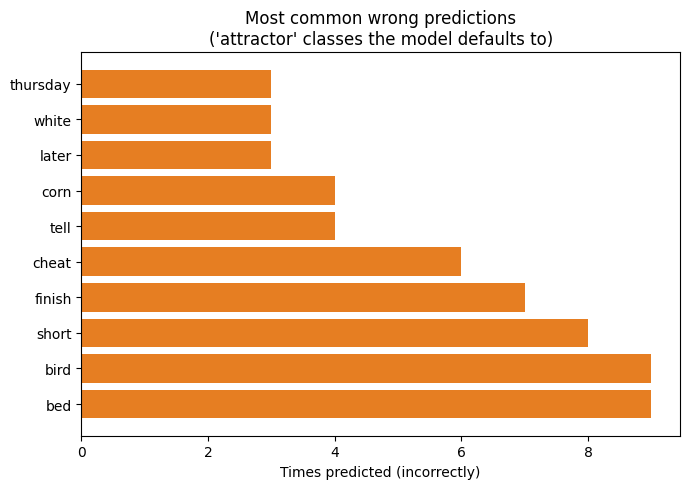

In [8]:
from collections import Counter

wrong_preds = [p["pred"] for p in predictions_log if not p["correct"]]
attractor_counts = Counter(wrong_preds).most_common(10)

fig, ax = plt.subplots(figsize=(7,5))
labels, counts = zip(*attractor_counts)
ax.barh(labels, counts, color="#e67e22")
ax.set_xlabel("Times predicted (incorrectly)")
ax.set_title("Most common wrong predictions\n('attractor' classes the model defaults to)")
plt.tight_layout()
plt.savefig(f'{CONFIG["output_dir"]}/attractor_classes.png', dpi=120)
plt.show()

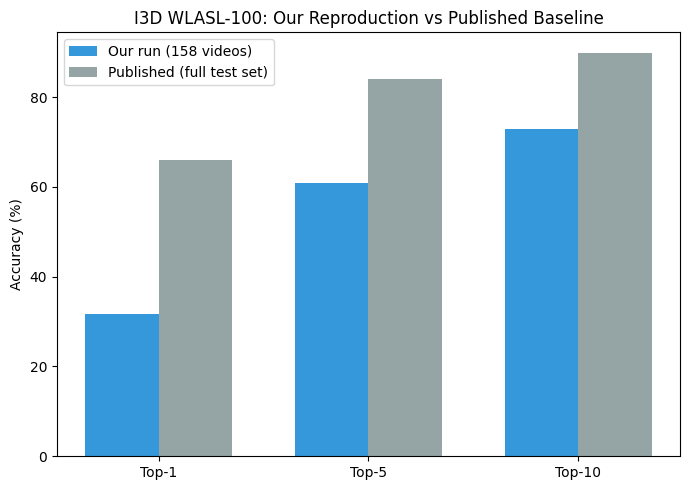

Saved baseline_comparison.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
metrics = ['Top-1', 'Top-5', 'Top-10']
ours = [top1_c/total*100, top5_c/total*100, top10_c/total*100]
published = [65.89, 84.11, 89.92]

x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, ours, width, label=f'Our run ({total} videos)', color='#3498db')
ax.bar(x + width/2, published, width, label='Published (full test set)', color='#95a5a6')
ax.set_ylabel('Accuracy (%)')
ax.set_title('I3D WLASL-100: Our Reproduction vs Published Baseline')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.legend()
plt.tight_layout()
plt.savefig(f'{CONFIG["output_dir"]}/baseline_comparison.png', dpi=120)
plt.show()
print("Saved baseline_comparison.png")

In [10]:
results = {
    "experiment": "I3D ASL Baseline Validation (WLASL-100)",
    "purpose": "Pipeline validation before PSL transfer experiments",
    "videos_evaluated": total,
    "videos_in_full_test_set": "~200 (some YouTube links unavailable)",
    "overall_accuracy": {
        "top1": round(top1_c/total*100, 2),
        "top5": round(top5_c/total*100, 2),
        "top10": round(top10_c/total*100, 2)
    },
    "published_baseline": {"top1": 65.89, "top5": 84.11, "top10": 89.92},
    "per_class_accuracy": {k: round(v*100, 2) for k, v in per_class.items()},
    "predictions_log": predictions_log
}
with open(f'{CONFIG["output_dir"]}/asl_validation_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f"Saved asl_validation_results.json")

Saved asl_validation_results.json


# Phase 1B: Pose-TGCN ASL Baseline Validation
### Second architecture for the benchmark matrix (Architecture B in the proposal)

**Model:** Pose-TGCN (Graph Convolutional Network over 55 OpenPose joints)  
**Input:** Pre-extracted skeleton keypoints — no raw video decoding required  
**Published baseline (WLASL-100):** Top-1: 55.43% | Top-5: 78.68% | Top-10: 87.60%

**Purpose:** Same validation logic as Phase 1A (I3D) — confirm this second, structurally
different architecture (skeleton-based vs. video-based) also reproduces its published
baseline before being applied to PSL. Together, I3D + Pose-TGCN validation establishes
that both rows of our benchmark matrix start from a verified, correct pipeline.

**Note:** Unlike I3D, this uses the dataset's full test split with no YouTube download
step — pose data is pre-extracted and bundled with the dataset, so sample size here is
not limited by dead video links.

In [42]:
import os
import gdown

# Setup directory
os.makedirs('/kaggle/working/WLASL/data', exist_ok=True)
%cd /kaggle/working/WLASL/data

# Use gdown to download
gdown.download(id='16CWkbMLyEbdBkrxAPaxSXFP_aSxKzNN4', output='splits.zip', quiet=True)
gdown.download(id='1k5mfrc2g4ZEzzNjW6CEVjLvNTZcmPanB', output='pose_data.zip', quiet=True)

# Extract quietly (-q) to prevent browser crash
print("Extracting files... (this may take a minute)")
!unzip -q -o splits.zip
!unzip -q -o pose_data.zip
print("Extraction complete!")

# Verify structure
print("\nVerifying files...")
!ls -d pose_per_individual_videos

/kaggle/working/WLASL/data
Extracting files... (this may take a minute)
Extraction complete!

Verifying files...
pose_per_individual_videos


In [62]:
!gdown '1dzvocsaylRsjqaY4r_lyRihPZn0I6AA_' -O /kaggle/working/archived.zip

Downloading...
From (original): https://drive.google.com/uc?id=1dzvocsaylRsjqaY4r_lyRihPZn0I6AA_
From (redirected): https://drive.google.com/uc?id=1dzvocsaylRsjqaY4r_lyRihPZn0I6AA_&confirm=t&uuid=c5a84389-8e1c-4c78-8988-840ae17adffd
To: /kaggle/working/archived.zip
100%|███████████████████████████████████████| 54.2M/54.2M [00:00<00:00, 105MB/s]


In [63]:
!mkdir -p /kaggle/working/WLASL/code/TGCN/archived/asl100/
!unzip -o /kaggle/working/archived.zip -d /kaggle/working/WLASL/code/TGCN/archived/asl100/

Archive:  /kaggle/working/archived.zip
   creating: /kaggle/working/WLASL/code/TGCN/archived/asl100/archived/
   creating: /kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl100/
  inflating: /kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl100/ckpt.pth  
  inflating: /kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl100/asl100.ini  
   creating: /kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl300/
  inflating: /kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl300/ckpt.pth  
  inflating: /kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl300/asl300.ini  
   creating: /kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl1000/
  inflating: /kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl1000/asl1000.ini  
  inflating: /kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl1000/ckpt.pth  
   creating: /kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl2000/
  inflating: /kaggle/working/WLASL/code

In [64]:
!find /kaggle/working/WLASL/code/TGCN/archived/asl100/ -name "ckpt.pth"

/kaggle/working/WLASL/code/TGCN/archived/asl100/ckpt.pth
/kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl100/ckpt.pth
/kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl1000/ckpt.pth
/kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl300/ckpt.pth
/kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl2000/ckpt.pth


In [66]:
!mv /kaggle/working/WLASL/code/TGCN/archived/asl100/archived/asl100/ckpt.pth /kaggle/working/WLASL/code/TGCN/archived/asl100/

In [67]:
!ls -lh /kaggle/working/WLASL/code/TGCN/archived/asl100/ckpt.pth

-rw-rw-r-- 1 root root 3.5M Jul 21  2019 /kaggle/working/WLASL/code/TGCN/archived/asl100/ckpt.pth


In [68]:
import os
import sys
import torch
import gc
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Define Paths
TGCN_DIR = "/kaggle/working/WLASL/code/TGCN"
trained_on = 'asl100'
ckpt_path = f'{TGCN_DIR}/archived/{trained_on}/ckpt.pth'
split_file = f'/kaggle/working/WLASL/data/splits/{trained_on}.json'
pose_data_root = f'/kaggle/working/WLASL/data/pose_per_individual_videos'
config_file = f'{TGCN_DIR}/configs/{trained_on}.ini'

# 2. Verify files exist before proceeding
if not os.path.exists(ckpt_path):
    print(f"CRITICAL ERROR: Checkpoint not found at {ckpt_path}")
    print("Run: !find /kaggle/working/WLASL -name 'ckpt.pth' to locate it.")
    sys.exit(1) # Stop execution if files are missing

# 3. Setup Environment
%cd {TGCN_DIR}
sys.path.insert(0, TGCN_DIR)

from configs import Config
from sign_dataset import Sign_Dataset
from tgcn_model import GCN_muti_att

# 4. Initialize Config and Dataset
configs = Config(config_file)
dataset = Sign_Dataset(
    index_file_path=split_file, 
    split='test', 
    pose_root=pose_data_root,
    img_transforms=None, 
    video_transforms=None,
    num_samples=configs.num_samples,
    sample_strategy='k_copies',
    test_index_file=split_file
)

# 5. Load the Model
model = GCN_muti_att(
    input_feature=configs.num_samples * 2, 
    hidden_feature=configs.hidden_size,
    num_class=int(trained_on[3:]), 
    p_dropout=configs.drop_p,
    num_stage=configs.num_stages
).cuda()

# Load weights safely
print(f"Loading weights from {ckpt_path}...")
model.load_state_dict(torch.load(ckpt_path))
model.eval()

# 6. Sanity check
print("-" * 30)
print(f"Classes in label encoder: {len(dataset.label_encoder.classes_)}")
print(f"Test set size: {len(dataset)} videos")
print(f"Model loaded successfully — Pose-TGCN WLASL-100")
print("-" * 30)

/kaggle/working/WLASL/code/TGCN
Trained on /kaggle/working/WLASL/data/splits/asl100.json, tested on /kaggle/working/WLASL/data/splits/asl100.json
Loading weights from /kaggle/working/WLASL/code/TGCN/archived/asl100/ckpt.pth...
------------------------------
Classes in label encoder: 100
Test set size: 258 videos
Model loaded successfully — Pose-TGCN WLASL-100
------------------------------


In [73]:
# Force the dataset to skip saving features to disk
dataset.save_to = None

In [ ]:
import io, contextlib, sys, time, os
import torch
import numpy as np
from sklearn.metrics import accuracy_score
import gc

# Ensure save_to is disabled to prevent disk space issues
dataset.save_to = None 

print("=== STEP 1: Initializing arrays ===")
top1_tp = np.zeros(100, dtype=int)
top1_fp = np.zeros(100, dtype=int)
predictions_log = []
all_y, all_y_pred, all_video_ids, all_pool_out = [], [], [], []
num_copies = 4
real_stdout = sys.stdout

print(f"=== STEP 2: Starting evaluation of {len(dataset)} videos ===\n")

# Using a buffer to capture output to avoid spamming the console
buf = io.StringIO()
print("=== STEP 3: Entering evaluation loop ===")

with torch.no_grad():
    for batch_idx, data in enumerate(data_loader):
        t0 = time.time()
        try:
            X, y, video_ids = data
            X, y = X.cuda(), y.cuda().view(-1,)
            
            all_output = []
            stride = X.size()[2] // num_copies
            for i in range(num_copies):
                # Ensure we don't pass empty slices
                chunk = X[:, :, i*stride:(i+1)*stride]
                if chunk.size(2) > 0:
                    output = model(chunk)
                    all_output.append(output)
            
            if all_output:
                output = torch.mean(torch.stack(all_output, dim=1), dim=1)
                y_pred = output.max(1, keepdim=True)[1]
                
                all_y.extend(y.cpu())
                all_y_pred.extend(y_pred.cpu())
                all_video_ids.extend(video_ids)
                all_pool_out.extend(output.cpu())
            
            del X, output, all_output
            torch.cuda.empty_cache(); gc.collect()
            print(f"  [batch {batch_idx+1}/{len(data_loader)}] done in {time.time()-t0:.1f}s — {len(all_y)} videos total")
            
        except Exception as e:
            print(f"  [batch {batch_idx+1}] ERROR: {e}")
            continue # Skip bad batches instead of crashing

print("=== STEP 6: Loop finished, computing metrics ===")
all_y = torch.stack(all_y).numpy()
all_y_pred = torch.stack(all_y_pred).squeeze().numpy()
all_pool_out = torch.stack(all_pool_out).numpy()

def compute_top_n(truths, preds, n):
    best_n = np.argsort(preds, axis=1)[:, -n:]
    return sum(truths[i] in best_n[i] for i in range(len(truths))) / len(truths)

top1acc = accuracy_score(all_y, all_y_pred)
top5acc = compute_top_n(all_y, all_pool_out, 5)
top10acc = compute_top_n(all_y, all_pool_out, 10)

print(f"\n{'='*55}\n{'OVERALL RESULTS — POSE-TGCN WLASL-100':^55}\n{'='*55}")
print(f"Videos evaluated: {len(all_y)}")
print(f"Top-1:  {top1acc*100:.2f}%")
print(f"Top-5:  {top5acc*100:.2f}%")
print(f"Top-10: {top10acc*100:.2f}%")
print(f"\nPublished baseline: Top-1: 55.43% | Top-5: 78.68% | Top-10: 87.60%")
print(f"{'='*55}")

=== STEP 1: Initializing arrays ===
=== STEP 2: Starting evaluation of 258 videos ===

=== STEP 3: Entering evaluation loop ===
/kaggle/working/WLASL/data/pose_per_individual_videos/07092/image_00001_keypoints.json
/kaggle/working/WLASL/data/pose_per_individual_videos/07092/image_00002_keypoints.json
/kaggle/working/WLASL/data/pose_per_individual_videos/07092/image_00003_keypoints.json
/kaggle/working/WLASL/data/pose_per_individual_videos/07092/image_00004_keypoints.json
/kaggle/working/WLASL/data/pose_per_individual_videos/07092/image_00005_keypoints.json
/kaggle/working/WLASL/data/pose_per_individual_videos/07092/image_00006_keypoints.json
/kaggle/working/WLASL/data/pose_per_individual_videos/07092/image_00007_keypoints.json
/kaggle/working/WLASL/data/pose_per_individual_videos/07092/image_00008_keypoints.json
/kaggle/working/WLASL/data/pose_per_individual_videos/07092/image_00009_keypoints.json
/kaggle/working/WLASL/data/pose_per_individual_videos/07092/image_00010_keypoints.json
/k

In [ ]:
per_class = {gloss_names[idx]: top1_tp[idx]/(top1_tp[idx]+top1_fp[idx])
             for idx in range(100) if (top1_tp[idx]+top1_fp[idx]) > 0}
sorted_acc = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
N = min(20, len(sorted_acc)//2)

fig, axes = plt.subplots(2, 1, figsize=(10, 9))
for ax, subset, title, color in zip(axes, [sorted_acc[:N], sorted_acc[-N:]],
    [f"Top {N} easiest signs (TGCN)", f"Bottom {N} hardest signs (TGCN)"], ["#2ecc71", "#e74c3c"]):
    ax.barh([x[0] for x in subset], [x[1] for x in subset], color=color)
    ax.set_xlim(0,1); ax.set_xlabel("Per-class accuracy"); ax.set_title(title)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(f'{CONFIG["output_dir"]}/tgcn_per_class_accuracy.png', dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(7,5))
x = np.arange(3); width = 0.35
ax.bar(x-width/2, [top1acc*100, top5acc*100, top10acc*100], width, label=f'Our run ({len(all_y)} videos)', color='#3498db')
ax.bar(x+width/2, [55.43, 78.68, 87.60], width, label='Published (full test set)', color='#95a5a6')
ax.set_xticks(x); ax.set_xticklabels(['Top-1','Top-5','Top-10']); ax.set_ylabel('Accuracy (%)')
ax.set_title('Pose-TGCN WLASL-100: Our Reproduction vs Published Baseline'); ax.legend()
plt.tight_layout()
plt.savefig(f'{CONFIG["output_dir"]}/tgcn_baseline_comparison.png', dpi=120)
plt.show()

import json, zipfile
results = {
    "experiment": "Pose-TGCN ASL Baseline Validation (WLASL-100)",
    "videos_evaluated": len(all_y),
    "overall_accuracy": {"top1": round(top1acc*100,2), "top5": round(top5acc*100,2), "top10": round(top10acc*100,2)},
    "published_baseline": {"top1": 55.43, "top5": 78.68, "top10": 87.60},
    "per_class_accuracy": {k: round(v*100,2) for k,v in per_class.items()},
    "predictions_log": predictions_log
}
with open(f'{CONFIG["output_dir"]}/tgcn_validation_results.json', 'w') as f:
    json.dump(results, f, indent=2)

with zipfile.ZipFile("/kaggle/working/tgcn_validation_results.zip", 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in ["tgcn_per_class_accuracy.png", "tgcn_baseline_comparison.png", "tgcn_validation_results.json"]:
        zf.write(f'{CONFIG["output_dir"]}/{fn}', f'outputs/{fn}')

print(f"\nTGCN validation complete — Top-1: {top1acc*100:.2f}% (published: 55.43%)")
print("Zip ready: /kaggle/working/tgcn_validation_results.zip")